# Step 3. 모델링 — RandomForest(베이스라인) → XGBoost + 결정 임계값 튜닝

**목표**: 전처리된 데이터로 불량 분류 모델을 학습하고, 불균형 데이터에 적합한 지표로 평가·비교한다.

**평가 원칙**
> Accuracy는 사용하지 않는다(모두 정상으로 찍어도 93%). 불량(Positive)을 놓치지 않는 것이 최우선이므로 **Recall**을 중심으로 **F1, ROC-AUC, Precision**을 함께 본다.

**핵심 포인트 — 임계값(threshold) 튜닝**
> 불균형 데이터에서는 기본 임계값 0.5가 거의 항상 불량을 놓친다(Recall≈0). 모델이 출력하는 불량 확률을 어느 선에서 "불량"으로 판정할지를 **교차검증으로 따로 정한다**. 이때 SMOTE를 CV 파이프라인 안에 넣어 누수 없이 튜닝한다.

**평가 데이터 주의**: 학습은 SMOTE로 균형 맞춘 train, 평가는 **실제 분포(불량 6.7%)를 유지한 test**로 한다.

## 0. 환경 설정 및 전처리 데이터 로드

In [1]:
# 라이브러리 import
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                             recall_score, precision_score, f1_score,
                             roc_auc_score, roc_curve, precision_recall_curve)

# 한글 폰트 (seaborn 스타일 먼저 → 폰트 지정)
sns.set_style('whitegrid')
mpl.rcParams['font.family'] = 'AppleGothic'
mpl.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110

FIG_DIR = os.path.join('..', 'outputs', 'figures')
PROC_DIR = os.path.join('..', 'data', 'processed')
MODEL_DIR = os.path.join('..', 'outputs', 'models')
os.makedirs(MODEL_DIR, exist_ok=True)
RANDOM_STATE = 42
print('준비 완료')

준비 완료


In [2]:
# 전처리 결과 로드 (02_preprocessing에서 저장한 npz)
data = np.load(os.path.join(PROC_DIR, 'secom_processed.npz'), allow_pickle=True)
X_train, y_train = data['X_train'], data['y_train']              # SMOTE 적용 (최종 학습용)
X_train_clean, y_train_clean = data['X_train_clean'], data['y_train_clean']  # SMOTE 전 (임계값 튜닝용)
X_test, y_test = data['X_test'], data['y_test']
feature_names = data['feature_names']

print(f'X_train(SMOTE) : {X_train.shape}, 클래스 {np.bincount(y_train)}')
print(f'X_train_clean  : {X_train_clean.shape}, 클래스 {np.bincount(y_train_clean)}')
print(f'X_test         : {X_test.shape}, 불량 {int(y_test.sum())}개 ({y_test.mean()*100:.2f}%)')

X_train(SMOTE) : (2340, 450), 클래스 [1170 1170]
X_train_clean  : (1253, 450), 클래스 [1170   83]
X_test         : (314, 450), 불량 21개 (6.69%)


In [3]:
# 공통 평가 함수: 주어진 임계값(threshold)으로 test 지표 계산
def evaluate(name, y_te, y_proba, threshold=0.5, show_report=True):
    y_pred = (y_proba >= threshold).astype(int)  # 임계값 이상이면 불량(1)
    metrics = {
        'model': name,
        'threshold': round(float(threshold), 3),
        'Recall': recall_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'F1': f1_score(y_te, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_te, y_proba),
    }
    if show_report:
        print(f'\n===== {name} (threshold={threshold:.3f}) =====')
        print(classification_report(y_te, y_pred, target_names=['정상', '불량'],
                                    digits=3, zero_division=0))
        print(f"Recall: {metrics['Recall']:.3f} | Precision: {metrics['Precision']:.3f} "
              f"| F1: {metrics['F1']:.3f} | ROC-AUC: {metrics['ROC-AUC']:.3f}")
    return metrics, y_pred

## 1. 모델 학습 및 기본 임계값(0.5)의 한계 확인

RandomForest(베이스라인)와 XGBoost를 SMOTE train으로 학습한 뒤, **기본 임계값 0.5**로 먼저 평가한다.
여기서 Recall이 무너지는 것을 직접 확인하고, 임계값 튜닝의 필요성을 데이터로 보인다.

In [4]:
# 두 모델 정의 및 학습 (SMOTE train)
rf = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE)
xgb = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4,
                    subsample=0.8, colsample_bytree=0.8,
                    eval_metric='auc', random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

# test 불량 확률
rf_proba = rf.predict_proba(X_test)[:, 1]
xgb_proba = xgb.predict_proba(X_test)[:, 1]

# 기본 임계값 0.5 평가
evaluate('RandomForest @0.5', y_test, rf_proba, 0.5)
evaluate('XGBoost @0.5', y_test, xgb_proba, 0.5)
print('\n※ 기본 0.5에서는 불량 확률이 0.5를 넘지 못해 Recall이 무너진다 → 임계값 튜닝 필요')


===== RandomForest @0.5 (threshold=0.500) =====
              precision    recall  f1-score   support

          정상      0.933     1.000     0.965       293
          불량      0.000     0.000     0.000        21

    accuracy                          0.933       314
   macro avg      0.467     0.500     0.483       314
weighted avg      0.871     0.933     0.901       314

Recall: 0.000 | Precision: 0.000 | F1: 0.000 | ROC-AUC: 0.805

===== XGBoost @0.5 (threshold=0.500) =====
              precision    recall  f1-score   support

          정상      0.933     0.997     0.964       293
          불량      0.000     0.000     0.000        21

    accuracy                          0.930       314
   macro avg      0.466     0.498     0.482       314
weighted avg      0.871     0.930     0.899       314

Recall: 0.000 | Precision: 0.000 | F1: 0.000 | ROC-AUC: 0.724

※ 기본 0.5에서는 불량 확률이 0.5를 넘지 못해 Recall이 무너진다 → 임계값 튜닝 필요


## 2. 결정 임계값 튜닝 (교차검증, 누수 방지)

임계값을 test로 정하면 test에 과적합된다. 따라서 **train에서 교차검증**으로 정한다.
`SMOTE → 분류기`를 하나의 imblearn 파이프라인으로 묶어 `cross_val_predict`를 돌리면, SMOTE가 각 fold의 학습 부분에만 적용되어 누수 없이 검증용(out-of-fold) 불량 확률을 얻는다.
이 확률에서 **F1을 최대화하는 임계값**을 선택한다(Recall과 Precision의 균형점).

In [5]:
# 교차검증으로 out-of-fold 불량 확률을 얻고, F1 최대 임계값을 찾는 함수
def tune_threshold(estimator, X_cl, y_cl):
    pipe = ImbPipeline([('smote', SMOTE(random_state=RANDOM_STATE)),
                        ('clf', estimator)])
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    # OOF(out-of-fold) 불량 확률 — 각 샘플이 학습에 안 쓰인 fold에서 예측된 확률
    oof_proba = cross_val_predict(pipe, X_cl, y_cl, cv=skf,
                                  method='predict_proba', n_jobs=-1)[:, 1]
    # precision_recall_curve로 임계값 후보별 P/R을 받아 F1 계산
    prec, rec, thr = precision_recall_curve(y_cl, oof_proba)
    f1s = 2 * prec * rec / (prec + rec + 1e-12)
    best_idx = int(np.argmax(f1s[:-1]))  # 마지막 점은 threshold가 없음
    best_thr = float(thr[best_idx])
    return best_thr, oof_proba, (prec, rec, thr, f1s)

# 각 모델의 임계값 튜닝 (학습되지 않은 새 인스턴스를 파이프라인에 사용)
rf_thr, rf_oof, rf_curve = tune_threshold(
    RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE),
    X_train_clean, y_train_clean)
xgb_thr, xgb_oof, xgb_curve = tune_threshold(
    XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4,
                  subsample=0.8, colsample_bytree=0.8,
                  eval_metric='auc', random_state=RANDOM_STATE, n_jobs=-1),
    X_train_clean, y_train_clean)

print(f'RandomForest 선택 임계값: {rf_thr:.3f}')
print(f'XGBoost      선택 임계값: {xgb_thr:.3f}')

/Users/kimmilim/Desktop/미림/2026-1/SK하이닉스_중반기/반도체플젝/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/kimmilim/Desktop/미림/2026-1/SK하이닉스_중반기/반도체플젝/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/kimmilim/Desktop/미림/2026-1/SK하이닉스_중반기/반도체플젝/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_d

/Users/kimmilim/Desktop/미림/2026-1/SK하이닉스_중반기/반도체플젝/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/kimmilim/Desktop/미림/2026-1/SK하이닉스_중반기/반도체플젝/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/kimmilim/Desktop/미림/2026-1/SK하이닉스_중반기/반도체플젝/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/kimmilim/Desktop/미림/2026-1/SK하이닉스_중반기/반도체플젝/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/kimmilim/Desktop/미림/2026-1/SK하이닉스_중반기/반도체플젝/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_d

RandomForest 선택 임계값: 0.320
XGBoost      선택 임계값: 0.116


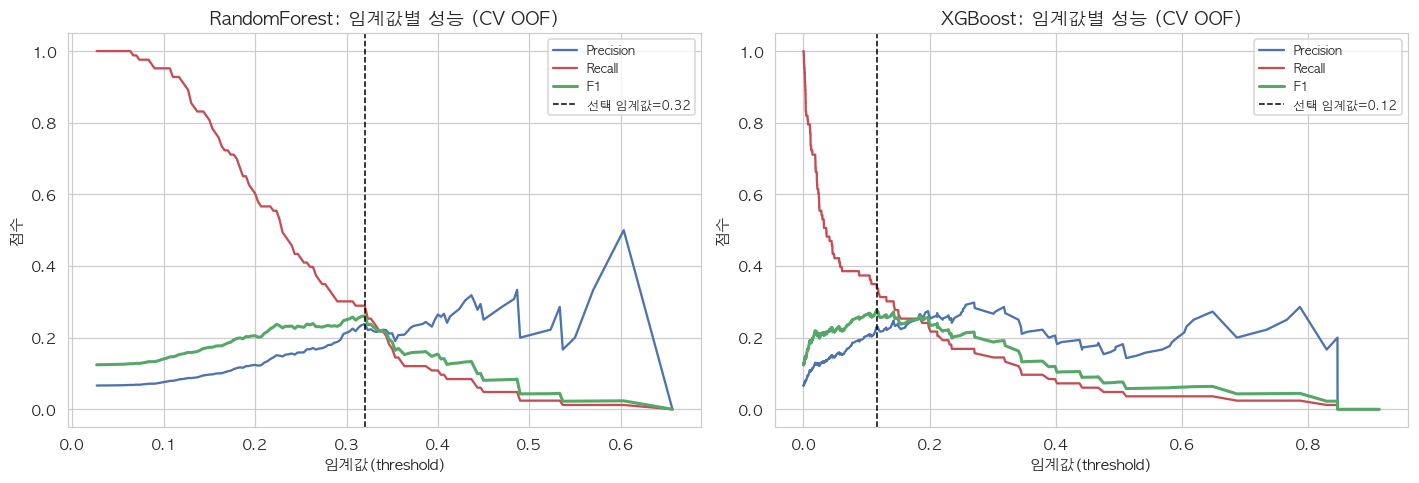

In [6]:
# 임계값에 따른 Precision/Recall/F1 변화 시각화 (교차검증 OOF 기준)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (curve, thr_sel, name) in zip(
        axes, [(rf_curve, rf_thr, 'RandomForest'), (xgb_curve, xgb_thr, 'XGBoost')]):
    prec, rec, thr, f1s = curve
    ax.plot(thr, prec[:-1], label='Precision', color='#4C72B0')
    ax.plot(thr, rec[:-1], label='Recall', color='#C44E52')
    ax.plot(thr, f1s[:-1], label='F1', color='#55A868', lw=2)
    ax.axvline(thr_sel, color='black', linestyle='--', lw=1,
               label=f'선택 임계값={thr_sel:.2f}')
    ax.set_title(f'{name}: 임계값별 성능 (CV OOF)')
    ax.set_xlabel('임계값(threshold)'); ax.set_ylabel('점수')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '07_threshold_tuning.png'), bbox_inches='tight')
plt.show()

## 3. 튜닝된 임계값으로 최종 평가 (test)

교차검증에서 정한 임계값을 **test에 그대로 적용**해 정직하게 평가한다.

In [7]:
# 튜닝된 임계값으로 test 평가
rf_metrics, rf_pred = evaluate('RandomForest', y_test, rf_proba, rf_thr)
xgb_metrics, xgb_pred = evaluate('XGBoost', y_test, xgb_proba, xgb_thr)


===== RandomForest (threshold=0.320) =====
              precision    recall  f1-score   support

          정상      0.952     0.942     0.947       293
          불량      0.292     0.333     0.311        21

    accuracy                          0.901       314
   macro avg      0.622     0.638     0.629       314
weighted avg      0.908     0.901     0.904       314

Recall: 0.333 | Precision: 0.292 | F1: 0.311 | ROC-AUC: 0.805

===== XGBoost (threshold=0.116) =====
              precision    recall  f1-score   support

          정상      0.951     0.925     0.938       293
          불량      0.241     0.333     0.280        21

    accuracy                          0.885       314
   macro avg      0.596     0.629     0.609       314
weighted avg      0.903     0.885     0.894       314

Recall: 0.333 | Precision: 0.241 | F1: 0.280 | ROC-AUC: 0.724


## 4. Confusion Matrix 비교

불량(Positive)을 얼마나 잡아내는지를 본다. 좌하단(FN, 실제 불량인데 정상 예측)이 수율 손실로 직결되는 가장 비싼 오류다.

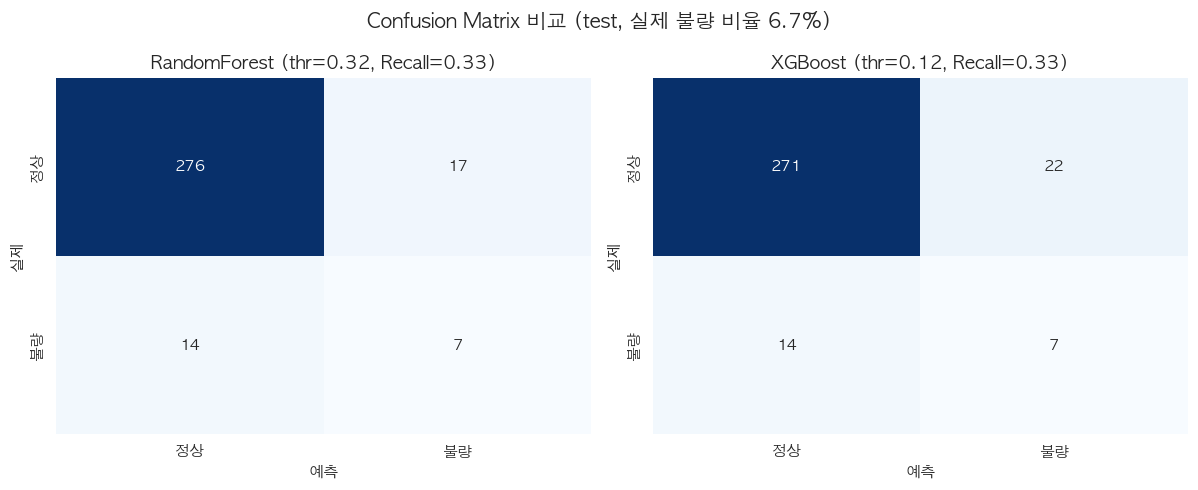

In [8]:
# 두 모델의 confusion matrix를 나란히 시각화 (튜닝 임계값 적용)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (pred, name, thr) in zip(
        axes, [(rf_pred, 'RandomForest', rf_thr), (xgb_pred, 'XGBoost', xgb_thr)]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['정상', '불량'], yticklabels=['정상', '불량'])
    ax.set_title(f'{name} (thr={thr:.2f}, Recall={recall_score(y_test, pred):.2f})')
    ax.set_xlabel('예측'); ax.set_ylabel('실제')
fig.suptitle('Confusion Matrix 비교 (test, 실제 불량 비율 6.7%)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '05_confusion_matrix.png'), bbox_inches='tight')
plt.show()

## 5. ROC Curve 비교

ROC-AUC는 임계값과 무관한 랭킹 성능 지표다. 곡선이 좌상단에 가까울수록 좋다.

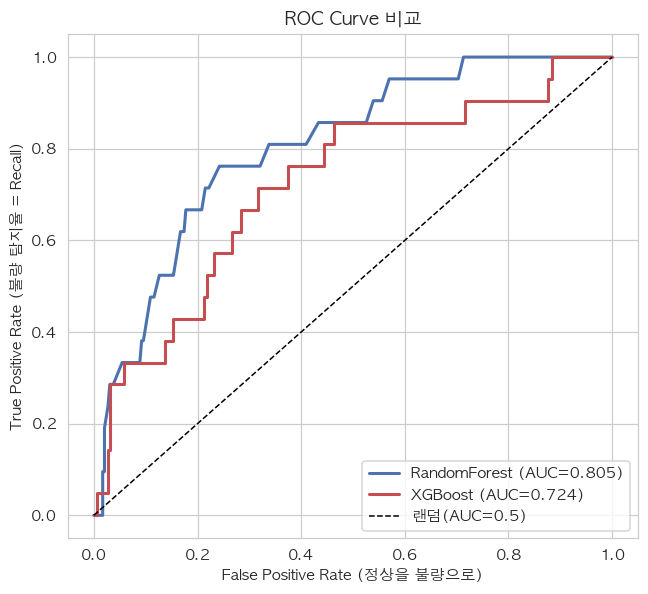

In [9]:
# ROC Curve 비교
fig, ax = plt.subplots(figsize=(6, 5.5))
for proba, name, color in [(rf_proba, 'RandomForest', '#4C72B0'),
                           (xgb_proba, 'XGBoost', '#C44E52')]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='랜덤(AUC=0.5)')
ax.set_xlabel('False Positive Rate (정상을 불량으로)')
ax.set_ylabel('True Positive Rate (불량 탐지율 = Recall)')
ax.set_title('ROC Curve 비교')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '06_roc_curve.png'), bbox_inches='tight')
plt.show()

## 6. 성능 비교 요약 및 모델 저장

In [10]:
# 두 모델 지표 비교 테이블 (불균형이므로 Accuracy는 의도적으로 제외)
compare = pd.DataFrame([rf_metrics, xgb_metrics]).set_index('model')
compare = compare[['threshold', 'Recall', 'Precision', 'F1', 'ROC-AUC']].round(3)
print('모델 성능 비교 (test 기준, 튜닝 임계값 적용)')
print(compare)

# 선택 기준: Recall 우선, 동률 시 F1
best_name = compare.sort_values(['Recall', 'F1'], ascending=False).index[0]
print(f'\n→ Recall 우선 기준 선택 모델: {best_name}')

모델 성능 비교 (test 기준, 튜닝 임계값 적용)
              threshold  Recall  Precision     F1  ROC-AUC
model                                                     
RandomForest      0.320   0.333      0.292  0.311    0.805
XGBoost           0.116   0.333      0.241  0.280    0.724

→ Recall 우선 기준 선택 모델: RandomForest


In [11]:
# 학습된 모델 + 튜닝 임계값 저장 (SHAP 분석 단계에서 재사용)
joblib.dump({'model': rf, 'threshold': rf_thr}, os.path.join(MODEL_DIR, 'random_forest.joblib'))
joblib.dump({'model': xgb, 'threshold': xgb_thr}, os.path.join(MODEL_DIR, 'xgboost.joblib'))
print('모델 저장 완료 → outputs/models/ (random_forest.joblib, xgboost.joblib)')
print(f'  RF threshold={rf_thr:.3f} | XGB threshold={xgb_thr:.3f}')

모델 저장 완료 → outputs/models/ (random_forest.joblib, xgboost.joblib)
  RF threshold=0.320 | XGB threshold=0.116


### 포트폴리오용 인사이트 (Step 3)

- **0.5 임계값의 함정을 실증**: SMOTE로 학습해도 기본 임계값 0.5에서는 Recall이 0에 가까웠다. 불균형 분류에서 임계값을 그대로 두면 불량을 전부 놓친다는 점을 데이터로 보였다.
- **누수 없는 임계값 선택**: SMOTE를 CV 파이프라인 안에 넣어 out-of-fold 확률로 임계값을 정했다. test로 임계값을 맞추는 흔한 실수(낙관적 편향)를 피한 점이 핵심 어필 포인트.
- **FN 비용 관점의 의사결정**: 임계값을 낮춰 Recall을 끌어올리면 Precision(헛경보)이 떨어지는 트레이드오프가 생긴다. 수율 손실로 직결되는 FN(놓친 불량)이 더 비싸다는 공정 관점에서 Recall을 우선했다.

**→ 다음 단계: `04_shap_analysis.ipynb` (선택 모델을 TreeExplainer로 분해 → 어떤 공정 변수가 불량 예측을 끌어올렸는지 해석)**